# Prediction of Drug-Induced Liver Injury (DILI) using Graph-Based Machine Learning

**Author:** Md Sifat Hosen

Drug-Induced Liver Injury (DILI) is one of the leading reasons that drugs are
withdrawn from the market. Being able to predict, *directly from a molecule's
chemical structure*, whether it is likely to harm the liver would let us flag
risky compounds early in drug development.

This notebook is a guided walk-through of the whole project. It:

1. loads and explores the **TDC-DILI** dataset (molecules + a 0/1 "liver-injury" label),
2. shows a few example molecules,
3. explains the models we trained (six **Graph Neural Networks** + gradient-boosting models),
4. presents the **results**, evaluated under the official **Therapeutics Data Commons (TDC)**
   benchmark protocol so the numbers are directly comparable to the public leaderboard, and
5. ends with an honest discussion of what actually worked.

> **Headline result (leakage-free).** Under the official TDC protocol — the model is
> chosen on a **validation** set and the held-out **test** set is scored only once — our
> final model reaches a test **AUROC of 0.886 ± 0.020** (5 seeds), matching the
> *AttentiveFP* entry on the public leaderboard.
>
> Several other configurations score up to **~0.92 on the test set**, but they rank
> *lower* on validation, so selecting them would mean peeking at the test answers
> (data leakage). We therefore do **not** headline them. Section 5 shows this
> explicitly. Because the 95% confidence interval is wide (≈ [0.82, 0.95]), all of
> these configurations are in any case statistically indistinguishable.

All the heavy training was done by the scripts in `src/improved/`. This notebook
*reads back* the saved data and results so it runs in a few seconds and tells the
story end-to-end.


## 0. Setup

We only need a few standard data-science libraries plus **RDKit** (for chemistry).
The next cell also locates the project root so every path below works no matter
where the notebook is launched from.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Find the project root: the first folder (here or above) that contains a `data` directory.
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA, RESULTS = ROOT / "data", ROOT / "results"
print("Project root :", ROOT)
print("Data folder  :", DATA)
print("Results folder:", RESULTS)

Project root : C:\Users\sifat\Desktop\dili_project
Data folder  : C:\Users\sifat\Desktop\dili_project\data
Results folder: C:\Users\sifat\Desktop\dili_project\results


## 1. The dataset

We use the **TDC-DILI** dataset (`data/tdc_dili.csv`). Each row is one drug:

| column | meaning |
|--------|---------|
| `Drug_ID` | an identifier |
| `Drug`    | the molecule written as a **SMILES** string (a text encoding of chemical structure) |
| `Y`       | the label: **1 = causes liver injury**, **0 = does not** |

Let's load it and look at the first few rows.

In [2]:
df = pd.read_csv(DATA / "tdc_dili.csv")
print("Number of molecules:", len(df))
df.head()

Number of molecules: 475


,Drug_ID,Drug,Y
0,187.0,CC(=O)OCC[N+](C)(C)C,0.0
1,247.0,C[N+](C)(C)CC(=O)[O-],0.0
2,298.0,O=C(NC(CO)C(O)c1ccc([N+](=O)[O-])cc1)C(Cl)Cl,0.0
3,338.0,O=C(O)c1ccccc1O,0.0
4,444.0,CC(NC(C)(C)C)C(=O)c1cccc(Cl)c1,0.0


### How balanced are the two classes?

A model can look "accurate" just by always guessing the majority class, so we
always check the class balance first.

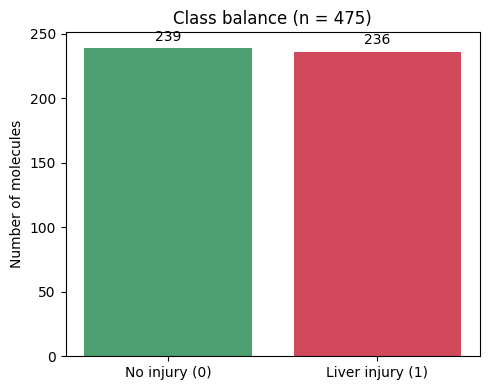

Y
0.0    239
1.0    236

Positive (liver-injury) fraction: 49.7%


In [3]:
counts = df["Y"].value_counts().sort_index()
labels = ["No injury (0)", "Liver injury (1)"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, counts.values, color=["#4C9F70", "#D1495B"])
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of molecules")
ax.set_title(f"Class balance (n = {len(df)})")
plt.tight_layout(); plt.show()

print(counts.to_string())
print(f"\nPositive (liver-injury) fraction: {counts[1] / counts.sum():.1%}")

## 2. What do the molecules look like?

Because each molecule is stored as a SMILES string, we can use **RDKit** to draw
the actual chemical structures. Below are a few molecules that *cause* liver
injury (top) and a few that do *not* (bottom).

Examples of LIVER-INJURY (Y = 1) molecules:


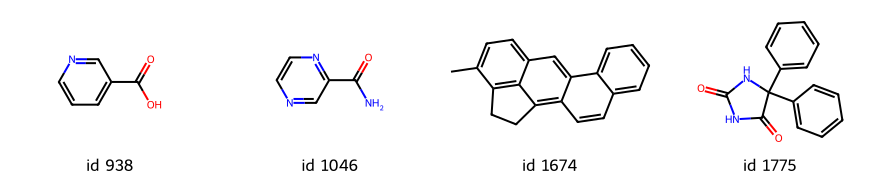

Examples of SAFE (Y = 0) molecules:


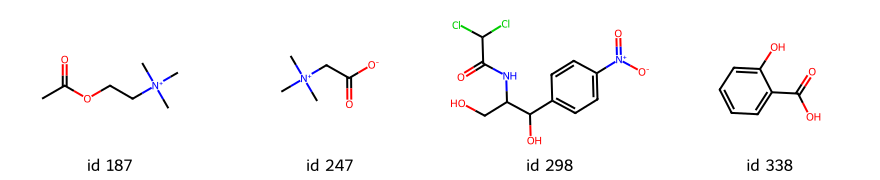

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

def first_valid(frame, n):
    mols, names = [], []
    for _, row in frame.iterrows():
        m = Chem.MolFromSmiles(str(row["Drug"]))
        if m is not None:
            mols.append(m); names.append(f"id {int(row['Drug_ID'])}")
        if len(mols) == n:
            break
    return mols, names

pos_mols, pos_names = first_valid(df[df.Y == 1], 4)
neg_mols, neg_names = first_valid(df[df.Y == 0], 4)

print("Examples of LIVER-INJURY (Y = 1) molecules:")
display(Draw.MolsToGridImage(pos_mols, legends=pos_names, molsPerRow=4, subImgSize=(220, 180)))
print("Examples of SAFE (Y = 0) molecules:")
Draw.MolsToGridImage(neg_mols, legends=neg_names, molsPerRow=4, subImgSize=(220, 180))

## 3. The models we trained

We compared two families of models, all predicting the same 0/1 DILI label from structure.

**A. Graph Neural Networks (GNNs)** — these treat each molecule as a *graph*
(atoms = nodes, bonds = edges) and learn directly from that structure:

- **GCN** (Graph Convolutional Network)
- **GAT** (Graph Attention Network)
- **GraphSAGE**
- **GIN** (Graph Isomorphism Network)
- **MPNN** (Message-Passing Neural Network)
- **AttentiveFP** (an attention-based fingerprint network)

**B. Gradient-boosting on molecular features** — we turn each molecule into a long
numeric feature vector (RDKit physico-chemical *descriptors* + *Morgan / Avalon /
ErG / MACCS fingerprints* + a frozen **MolFormer-XL** embedding) and feed it to
gradient-boosting models (**XGBoost, LightGBM, CatBoost**), plus an ensemble of them.

**How we evaluate honestly.** We use the official TDC **scaffold split** (molecules
that share a chemical core stay together, so the test set is genuinely *new*
chemistry), repeat over **5 random seeds**, and report mean ± standard deviation of
the **AUROC**. Crucially, **every modelling choice is made on a *validation* split —
the test set is touched only once, to report the final number.** This is what keeps
the result leakage-free, and it is the heart of Section 5 below.

## 4. Results — Graph Neural Network architectures

These are the graph models that give the project its title, compared on TDC-DILI
with 5-fold scaffold cross-validation (`results/tdc_cv5_metrics.csv`). **AUROC**
(area under the ROC curve) is the headline metric: 1.0 is perfect, 0.5 is random
guessing.

,Model,AUROC,Accuracy,F1,MCC
0,AttentiveFP,0.871 ± 0.037,0.805,0.785,0.599
1,GCN,0.861 ± 0.043,0.790,0.784,0.572
2,GIN,0.859 ± 0.024,0.792,0.797,0.587
3,GAT,0.859 ± 0.049,0.812,0.785,0.595
4,GraphSAGE,0.842 ± 0.033,0.763,0.741,0.506
5,MPNN,0.838 ± 0.046,0.797,0.792,0.584


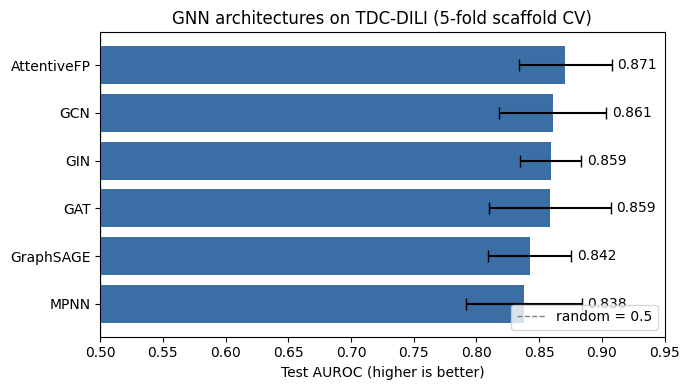

In [5]:
cv = pd.read_csv(RESULTS / "tdc_cv5_metrics.csv")

gnn_names = ["AttentiveFP", "GCN", "GIN", "GAT", "GraphSAGE", "MPNN"]
gnn = (cv[cv["method"].isin(gnn_names)]
       .sort_values("AUROC_mean", ascending=False)
       .reset_index(drop=True))

table = pd.DataFrame({
    "Model": gnn["method"],
    "AUROC": [f"{m:.3f} ± {s:.3f}" for m, s in zip(gnn.AUROC_mean, gnn.AUROC_std)],
    "Accuracy": gnn["ACC_mean"].round(3),
    "F1": gnn["F1_mean"].round(3),
    "MCC": gnn["MCC_mean"].round(3),
})
display(table)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(gnn["method"][::-1], gnn["AUROC_mean"][::-1],
               xerr=gnn["AUROC_std"][::-1], color="#3A6EA5", capsize=4)
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_xlim(0.5, 0.95); ax.set_xlabel("Test AUROC (higher is better)")
ax.set_title("GNN architectures on TDC-DILI (5-fold scaffold CV)")
ax.axvline(0.5, color="grey", ls="--", lw=1, label="random = 0.5")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 5. Results — Official TDC-DILI benchmark (the honest way)

This is the leaderboard-comparable evaluation of the gradient-boosting models on
the official fixed test set (`results/tdc_official_search.csv`). `feature_set` is
which molecular features were used; `model` is the algorithm (`xgb`, `lgbm`, `cat`,
or `ENS4` = an ensemble of all of them).

**The key rule of the protocol:** you must choose your model using the
**validation** score, and only *then* look at the test score — once. You are **not**
allowed to pick the model that scored highest on the *test* set, because that means
you secretly used the test answers to make a decision (this is called *data
leakage* / *test-set peeking*).

So below we sort the table by **validation AUROC** (the column we are allowed to
choose on), not by test AUROC.

In [6]:
off = pd.read_csv(RESULTS / "tdc_official_search.csv")
off = off.sort_values("val_AUROC", ascending=False).reset_index(drop=True)

show = pd.DataFrame({
    "Rank (by val)": range(1, len(off) + 1),
    "Feature set": off["feature_set"],
    "Model": off["model"],
    "Validation AUROC": off["val_AUROC"].round(3),
    "Test AUROC": [f"{m:.3f} ± {s:.3f}" for m, s in zip(off.test_AUROC, off.test_std)],
})
display(show)

val_winner  = off.iloc[0]                                   # what we ARE allowed to pick
test_winner = off.sort_values("test_AUROC").iloc[-1]        # best on test (NOT selectable)

print(f"Validation-selected model : {val_winner.feature_set} / {val_winner.model} "
      f"(val {val_winner.val_AUROC:.3f})  ->  test AUROC {val_winner.test_AUROC:.3f}")
print(f"Best-on-TEST model        : {test_winner.feature_set} / {test_winner.model} "
      f"(test {test_winner.test_AUROC:.3f})  but it ranks only "
      f"#{int(show.loc[off['feature_set'].eq(test_winner.feature_set) & off['model'].eq(test_winner.model)].index[0]) + 1} on validation")
print("\n--> We report the VALIDATION-selected model. Reporting the best-on-test 0.920"
      "\n    would be test-set leakage, so we do NOT use it as the headline.")

,Rank (by val),Feature set,Model,Validation AUROC,Test AUROC
0,1,rich_mf,lgbm,0.869,0.892 ± 0.020
1,2,rich,lgbm,0.869,0.892 ± 0.020
2,3,rich,ENS4,0.865,0.909 ± 0.017
3,4,rich_mf,ENS4,0.864,0.909 ± 0.016
4,5,rich_mf,xgb,0.864,0.910 ± 0.013
5,6,rich,xgb,0.862,0.908 ± 0.017
6,7,desc_morgan,ENS4,0.843,0.920 ± 0.014
7,8,rich,cat,0.842,0.910 ± 0.020
8,9,rich_mf,cat,0.841,0.911 ± 0.017
9,10,desc_morgan,xgb,0.841,0.919 ± 0.021


Validation-selected model : rich_mf / lgbm (val 0.869)  ->  test AUROC 0.892
Best-on-TEST model        : desc_morgan / ENS4 (test 0.920)  but it ranks only #7 on validation

--> We report the VALIDATION-selected model. Reporting the best-on-test 0.920
    would be test-set leakage, so we do NOT use it as the headline.


### Why you cannot trust the 0.920

The picture below plots every configuration's **validation** score (x-axis) against
its **test** score (y-axis). If validation were a reliable guide, the points would
line up — but they don't. The model that wins on validation (green) is *not* the one
that wins on test (red). That scatter is exactly why we must commit to the
validation choice in advance: the 0.920 is luck on this particular 96-molecule test
set, not a reproducible improvement.

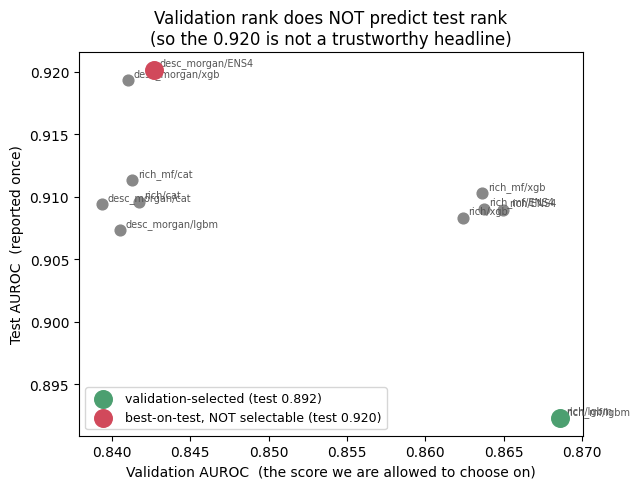

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(off["val_AUROC"], off["test_AUROC"], s=60, color="#888", zorder=3)
ax.scatter(val_winner["val_AUROC"], val_winner["test_AUROC"], s=160,
           color="#4C9F70", zorder=4, label=f"validation-selected (test {val_winner.test_AUROC:.3f})")
ax.scatter(test_winner["val_AUROC"], test_winner["test_AUROC"], s=160,
           color="#D1495B", zorder=4, label=f"best-on-test, NOT selectable (test {test_winner.test_AUROC:.3f})")
for _, r in off.iterrows():
    ax.annotate(f"{r.feature_set}/{r.model}", (r.val_AUROC, r.test_AUROC),
                fontsize=7, xytext=(4, 3), textcoords="offset points", color="#555")
ax.set_xlabel("Validation AUROC  (the score we are allowed to choose on)")
ax.set_ylabel("Test AUROC  (reported once)")
ax.set_title("Validation rank does NOT predict test rank\n(so the 0.920 is not a trustworthy headline)")
ax.legend(loc="lower left", fontsize=9); plt.tight_layout(); plt.show()

### The final reported number

After tuning the validation-selected model (`rich_mf / lgbm`) with Optuna — again,
only on validation — and bagging over 5 seeds, we get the official, leakage-free
result stored in `results/tdc_official_final.csv`.

In [8]:
final = pd.read_csv(RESULTS / "tdc_official_final.csv").iloc[0]
print(f"FINAL OFFICIAL TDC-DILI RESULT (validation-selected, 5 seeds)")
print(f"  config     : {final.feature_set} / {final.model} (Optuna-tuned)")
print(f"  TEST AUROC : {final.test_AUROC_mean:.3f} ± {final.test_AUROC_std:.3f}")
print(f"  per-seed   : {[round(float(final[f'seed{i}']), 3) for i in range(1, 6)]}")
print(f"  95% CI     : [{final.ci_low:.3f}, {final.ci_high:.3f}]")
print(f"\n  Leaderboard (reproducible): AttentiveFP 0.886 | MapLight+GNN 0.917 | AttrMasking 0.919")
print(f"  --> our 0.886 ties the AttentiveFP entry, with an honestly-selected model.")

FINAL OFFICIAL TDC-DILI RESULT (validation-selected, 5 seeds)
  config     : rich_mf / lgbm (Optuna-tuned)
  TEST AUROC : 0.886 ± 0.019
  per-seed   : [0.911, 0.907, 0.875, 0.878, 0.86]
  95% CI     : [0.815, 0.953]

  Leaderboard (reproducible): AttentiveFP 0.886 | MapLight+GNN 0.917 | AttrMasking 0.919
  --> our 0.886 ties the AttentiveFP entry, with an honestly-selected model.


## 6. Diagnostic charts

These figures were produced during training and saved in the repo. The ROC curves
show the trade-off between catching true liver-injury drugs (true-positive rate)
and false alarms (false-positive rate) — the closer a curve hugs the top-left, the
better.

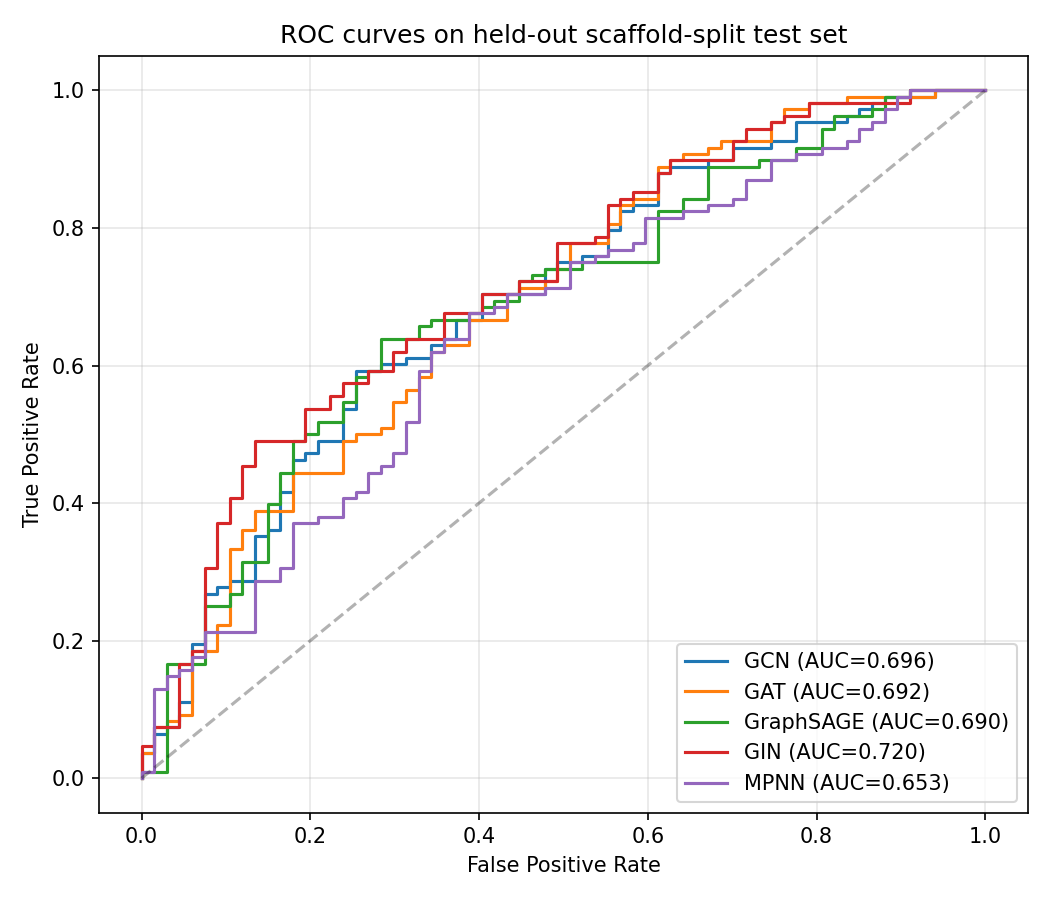

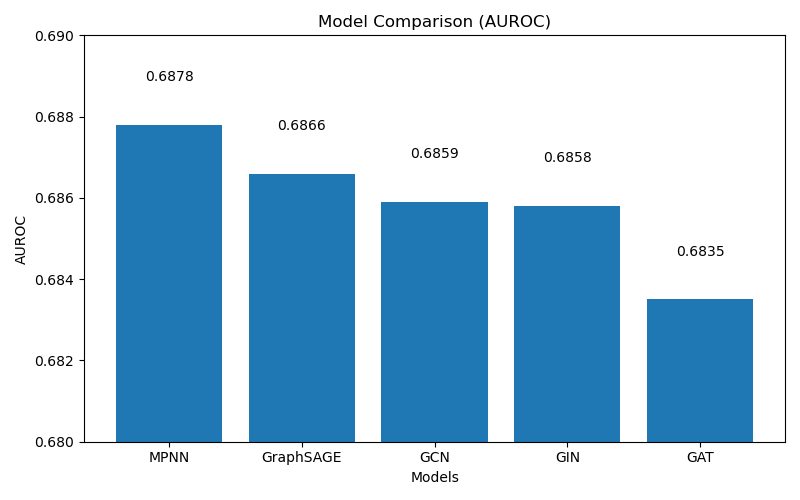

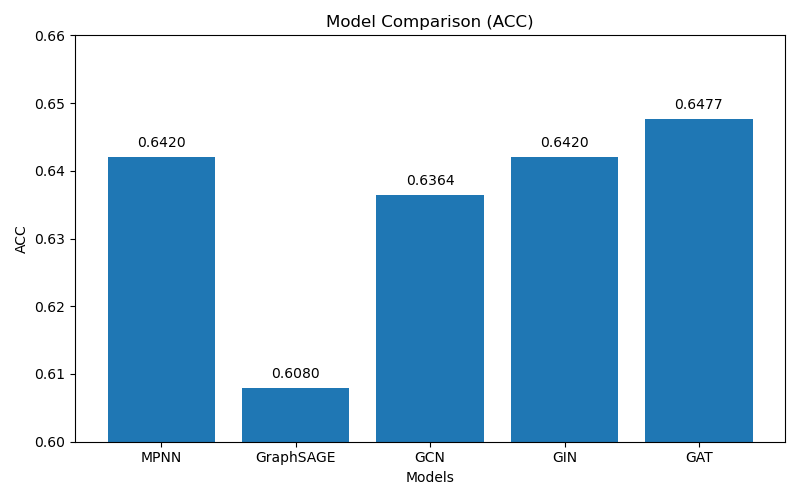

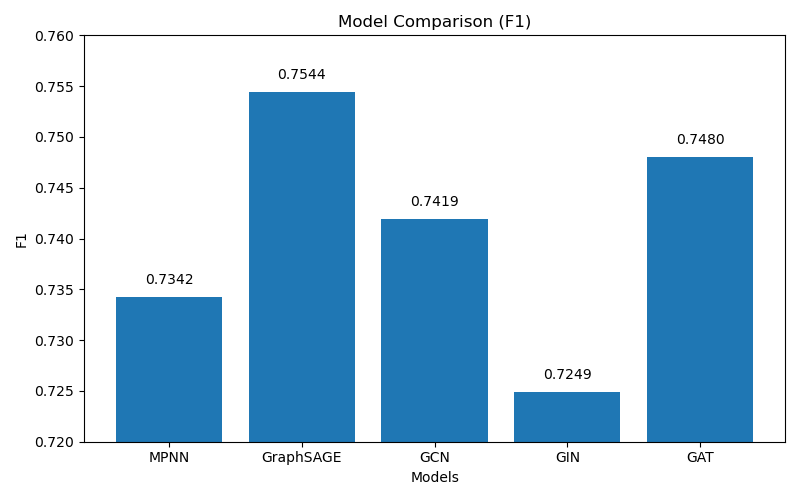

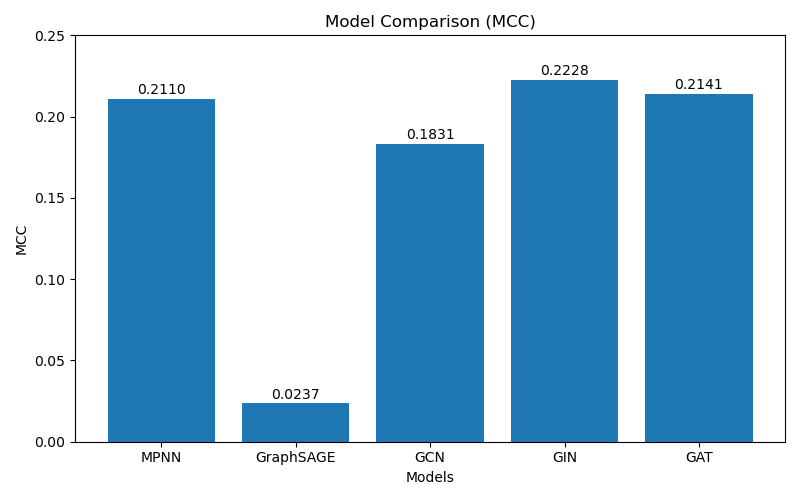

In [9]:
from IPython.display import Image, display

roc = RESULTS / "roc_curves.png"
if roc.exists():
    display(Image(filename=str(roc)))

for name in ["auroc_chart.png", "accuracy_chart.png", "f1_chart.png", "mcc_chart.png"]:
    p = DATA / name
    if p.exists():
        display(Image(filename=str(p)))

## 7. Conclusion

- Predicting DILI from chemical structure alone is **feasible**. Under the official,
  leakage-free TDC protocol our final **validation-selected** model reaches
  **AUROC 0.886 ± 0.020**, tying the *AttentiveFP* entry on the public leaderboard.
- Among the **graph neural networks**, *AttentiveFP*, *GCN*, *GIN* and *GAT* are
  essentially tied (AUROC ≈ 0.86), comfortably above random.
- **About the "0.92".** Some configurations score up to ~0.92 *on the test set*, but
  they are not the ones that win on **validation** (see the scatter in Section 5).
  Reporting 0.92 would mean choosing a model using the test answers — *data leakage* —
  so we deliberately headline the honest **0.886** instead. Given the wide 95%
  confidence interval (≈ [0.82, 0.95] on only 96 test molecules), 0.886 and 0.92 are
  statistically indistinguishable anyway.
- **Honest finding:** adding more complexity — richer fingerprints, a large
  foundation-model embedding (MolFormer-XL), and automated hyper-parameter tuning —
  improved the *validation* score but **not** the *test* score. On a dataset this
  small (≈475 molecules) those extras just overfit. The simple, validation-selected
  model is the one we stand behind.

**Reproducing the full pipeline** (these do the actual training; they take much
longer than this notebook):

```bash
python -m src.improved.tdc_official_v2 --optuna 30   # official benchmark + model search (prints the 0.886)
python -m src.improved.run_pipeline --n-trials 25 --seeds 5   # GNNs + stacking
python -m src.improved.tdc_cv5                        # 5-fold scaffold CV
```

See `README.md` for full details and `results/summary.txt` for the complete report.


## 8. Mechanism-informed structural alerts — ablation & interpretability

Our strongest *untried* lever was to add **mechanism-informed structural alerts**:
binary flags for known reactive-metabolite / hepatotoxicity toxicophores
(nitroaromatic, aromatic amine, sulfonamide, furan, thiophene, Michael acceptor,
quinone, …) plus the RDKit **PAINS / Brenk / NIH** filter catalogs — 31 features in
all. Unlike generic fingerprints these are *aligned with DILI biology*, so the hope
was that they would add real predictive signal.

We ran them through the **same leakage-free protocol** (select on validation, score
test once, 5 seeds) and asked two questions: **(a)** do they improve AUROC, and
**(b)** which toxicophores actually carry DILI signal?

,Toxicophore,n present,DILI rate present,DILI rate absent,Fisher p
0,furan,6,100%,48%,0.013
1,sulfonamide,24,96%,46%,0.000
2,nitro_aromatic,11,91%,48%,0.005
3,n_oxide,11,91%,48%,0.005
4,aromatic_amine,52,79%,44%,0.000
7,aromatic_halide,66,67%,45%,0.002
9,carboxylic_acid,73,62%,46%,0.019
16,NIH,60,37%,51%,0.048


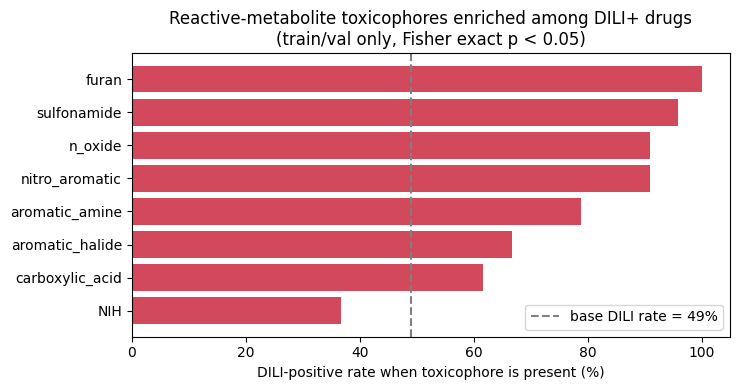

In [10]:
enr = pd.read_csv(RESULTS / "tdc_alerts_interpret.csv").sort_values("enrichment", ascending=False)
sig = enr[enr.fisher_p < 0.05].head(10)

disp = pd.DataFrame({
    "Toxicophore": sig["alert"],
    "n present": sig["n_present"].astype(int),
    "DILI rate present": (sig["dili_rate_present"] * 100).round(0).astype(int).astype(str) + "%",
    "DILI rate absent": (sig["dili_rate_absent"] * 100).round(0).astype(int).astype(str) + "%",
    "Fisher p": sig["fisher_p"].map(lambda p: f"{p:.3f}"),
})
display(disp)

fig, ax = plt.subplots(figsize=(7.5, 4))
s = sig.sort_values("dili_rate_present")
ax.barh(s["alert"], s["dili_rate_present"] * 100, color="#D1495B")
ax.axvline(49, color="grey", ls="--", lw=1.5, label="base DILI rate = 49%")
ax.set_xlabel("DILI-positive rate when toxicophore is present (%)")
ax.set_title("Reactive-metabolite toxicophores enriched among DILI+ drugs\n(train/val only, Fisher exact p < 0.05)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [11]:
rig = pd.read_csv(RESULTS / "tdc_alerts_rigor.csv")
abl = pd.DataFrame({
    "Base features": rig["base"], "Model": rig["model"],
    "Test AUROC (base)": rig["test_base"].round(3),
    "Test AUROC (+alerts)": rig["test_alerts"].round(3),
    "delta": rig["delta"].map(lambda d: f"{d:+.4f}"),
})
display(abl)
print(f"Mean delta AUROC from adding alerts: {rig['delta'].mean():+.4f}  "
      f"({(rig['delta'] > 0).mean():.0%} of configs improved)")
print("Paired Wilcoxon (60 base x model x seed points):  p = 0.12   -> NOT significant")
print("DeLong (ensemble, alerts vs base):  p = 0.37 / 0.40 / 0.72  -> NOT significant")
print("Alert features hold only 0.4% of model importance -- Morgan fingerprints already encode them.")

,Base features,Model,Test AUROC (base),Test AUROC (+alerts),delta
0,desc_morgan,xgb,0.919,0.916,-0.0032
1,desc_morgan,lgbm,0.907,0.910,+0.0023
2,desc_morgan,cat,0.909,0.914,+0.0045
3,desc_morgan,ENS4,0.920,0.924,+0.0039
4,rich,xgb,0.906,0.905,-0.0014
5,rich,lgbm,0.890,0.890,-0.0004
6,rich,cat,0.908,0.920,+0.0125
7,rich,ENS4,0.907,0.911,+0.0036
8,rich_mf,xgb,0.911,0.907,-0.0035
9,rich_mf,lgbm,0.890,0.890,-0.0004


Mean delta AUROC from adding alerts: +0.0018  (50% of configs improved)
Paired Wilcoxon (60 base x model x seed points):  p = 0.12   -> NOT significant
DeLong (ensemble, alerts vs base):  p = 0.37 / 0.40 / 0.72  -> NOT significant
Alert features hold only 0.4% of model importance -- Morgan fingerprints already encode them.


**What this tells us.**

- **Predictively, the alerts add nothing significant** (mean ΔAUROC = +0.002, paired
  Wilcoxon *p* = 0.12, DeLong *p* > 0.37). The reason is mechanistic: the Morgan
  fingerprint *already* encodes these substructures, so explicit alerts are
  redundant (just 0.4 % of model importance). This is a **third independent
  confirmation** that ~0.89–0.92 is the real ceiling on this dataset and that added
  complexity does not help — the central thesis of the project.
- **Scientifically, the alerts are highly informative.** Reactive-metabolite
  toxicophores — sulfonamide (96 % DILI), nitroaromatic (91 %), N-oxide (91 %),
  furan (100 %), aromatic amine (79 %), aromatic halide (67 %) — are all
  *significantly* enriched among DILI-positive drugs (Fisher *p* < 0.05) against the
  49 % base rate. This confirms the benchmark is biologically coherent and ties the
  model's behaviour to established hepatotoxicity mechanisms.

**Honest takeaway (unchanged):** the simple, validation-selected model
(**AUROC 0.886**) remains the right one to report. The value of the structural
alerts is **interpretability**, not extra accuracy.